In [1]:
import random

import mlflow
import numpy as np
import pyarrow.parquet as pq
import torch.cuda
from torch import nn
from torch.utils.data import Dataset, WeightedRandomSampler, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH = 128
EPOCHS = 30
LR = 1e-3
NUM_CLASSES = 8
DATA_DIR = "../data/processed"

print(f"Device: {DEVICE}")

Device: cuda


In [2]:
LABELS = ["Center", "Donut", "Edge-Loc", "Edge-Ring", "Loc", "Near-full", "Random", "Scratch"]
LABEL2IDX = {name: i for i, name in enumerate(LABELS)}


class WaferDataset(Dataset):
    def __init__(self, parquet_path: str):
        table = pq.read_table(parquet_path)
        df = table.to_pandas()
        wafers = np.stack(df["wafer"].values)
        self.X = wafers.reshape(-1, 1, 64, 64).astype(np.float32)
        self.y = df["label"].map(LABEL2IDX).values.astype(np.int64)
        assert not np.isnan(self.y).any(), "Unknown label found"

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), int(self.y[idx])


train_ds = WaferDataset(f"{DATA_DIR}/train.parquet")
val_ds = WaferDataset(f"{DATA_DIR}/val.parquet")
test_ds = WaferDataset(f"{DATA_DIR}/test.parquet")

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
print(f"X shape={train_ds.X.shape}, dtype={train_ds.X.dtype}")


Train: 17863, Val: 3828, Test: 3828
X shape=(17863, 1, 64, 64), dtype=float32


In [3]:
# count samples per classes in the training set
class_counts = np.bincount(train_ds.y, minlength=NUM_CLASSES)
for i, name in enumerate(LABELS):
    print(f"{name:12s}: {class_counts[i]}")

# Weight per class = inverse frequency -> rare classes get higher weight
class_weights = 1.0 / class_counts
# Assign each sample the weight of its class
sample_weights = class_weights[train_ds.y]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),  # sampler requires float64
    num_samples=len(sample_weights),  # keep one epoch ~= dataset size
    replacement=True
)

print(f"Sampler ready, {len(sample_weights)} samples")

Center      : 3006
Donut       : 389
Edge-Loc    : 3632
Edge-Ring   : 6776
Loc         : 2515
Near-full   : 104
Random      : 606
Scratch     : 835
Sampler ready, 17863 samples


In [4]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    sampler=sampler,  # weighted sampling -> no shuffle (sample controls order)
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    shuffle=False,  # natural distribution, order irrelevant for eval
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Sanity check
xb, yb = next(iter(train_loader))
print(f"batch X: {xb.shape}  {yb.dtype}")  # expect [128, 1, 64, 64] float32
print(f"batch y: {yb.shape}  {yb.dtype}")  # expect [128] int64
print(f"class count in this batch: {np.bincount(yb.numpy(), minlength=NUM_CLASSES)}")

batch X: torch.Size([128, 1, 64, 64])  torch.int64
batch y: torch.Size([128])  torch.int64
class count in this batch: [13 22 17 15 15 14 10 22]


In [5]:
class WaferCNN(nn.Module):
    """Small baseline CNN for 64x64 single channel wafer maps."""

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            # block 1: 1-> 32, 64x64 -> 32 x 32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # block 2: 32 -> 64, 32 x 32 -> 16 x 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # block 3: 64 -> 128, 16 x 16 -> 8 x 8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # 128x8x8 -> 128x1x1, robust to size changes
            nn.Flatten(),  # -> [N, 128]
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x / 2.0  # normalize die values {0, 1, 2} -> {0, 0.5, 1.0}
        x = self.features(x)
        x = self.classifier(x)
        return x


model = WaferCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"trainable params: {n_params:,}")

for name, p in model.named_parameters():
    print(f"{name:35s} {str(type(p.shape)):20s} {p.numel():>8,}")

# Forward sanity check on each batch
with torch.no_grad():
    out = model(xb.to(DEVICE))
print(f"output shape: {out.shape}")  # expect [128,8]

WaferCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim

In [6]:
# γ và β init of BatchNorm — weight = γ, bias = β
bn = model.features[1]  # BatchNorm2d(32)
print("γ (weight):", bn.weight.data[:5])  # all 1.0
print("β (bias):  ", bn.bias.data[:5])  # all 0.0

# He-init randomly
conv = model.features[0]  # Conv2d(1, 32)
print("conv weight:", conv.weight.data[0, 0])  # 3×3 random small number

γ (weight): tensor([1., 1., 1., 1., 1.], device='cuda:0')
β (bias):   tensor([0., 0., 0., 0., 0.], device='cuda:0')
conv weight: tensor([[ 0.2048,  0.1338,  0.2557],
        [-0.2877,  0.2651, -0.0399],
        [-0.0570,  0.1748,  0.0881]], device='cuda:0')


In [7]:
from pathlib import Path

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam, a solid default for CNNs
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Mlflow: point to a local tracking dir and name the experiment
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
db_path = PROJECT_ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("wm811k-baseline-cnn")

print("criterion, optimizer, and experiment set up!")

criterion, optimizer, and experiment set up!


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # enable Dropout + BatchNorm use batch stats
    running_loss = 0.0
    n_samples = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()  # clear gradients from previous step
        logits = model(xb)  # forward
        loss = criterion(logits, yb)  # how wrong
        loss.backward()  # backprop: compute gradients
        optimizer.step()  # nudge parameters

        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)
    return running_loss / n_samples


@torch.no_grad()  # no gradients needed for eval -> faster, less memory
def evaluate(model, loader, criterion, device):
    model.eval()  # disables Dropout + BatchNorm uses running stats
    running_loss = 0.0
    n_samples = 0
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)
        all_preds.append(logits.argmax(dim=1).cpu())
        all_labels.append(yb.cpu())

    avg_loss = running_loss / n_samples
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return avg_loss, preds, labels


print("train/eval functions ready!")

train/eval functions ready!


In [9]:
# Macro-F1: unweighted mean over classes -> rare classes count equally
from sklearn.metrics import f1_score

best_val_loss = float("inf")
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
best_path = MODEL_DIR / "wafercnn_best.pt"

# Params logged once per run for reproducibility
run_params = {
    "model": "WaferCNN",
    "epochs": EPOCHS,
    "batch_size": BATCH,
    "lr": LR,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss",
    "sampler": "WeightedRandomSampler",
    "seed": SEED,
    "img_size": 64,
    "num_classes": NUM_CLASSES,
}

with mlflow.start_run(run_name="baseline-cnn"):
    mlflow.log_params(run_params)
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
                                     device=DEVICE)
        val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion, device=DEVICE)
        val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")

        mlflow.log_metrics(
            metrics={
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_macro_f1": val_macro_f1,
            }, step=epoch
        )

        print(
            f"epoch {epoch:2d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | val macro-F1: {val_macro_f1:.4f}")

        # Save the best by val_loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
            mlflow.log_artifact(str(best_path))
            print(f"\t-> saved best (val_loss {val_loss:.4f})")

print(f"\nDone! Best val_loss: {best_val_loss:.4f}")

epoch  1 | train loss: 1.1579 | val loss: 0.8682 | val macro-F1: 0.5655
	-> saved best (val_loss 0.8682)
epoch  2 | train loss: 0.8179 | val loss: 0.9861 | val macro-F1: 0.5639
epoch  3 | train loss: 0.7239 | val loss: 0.9854 | val macro-F1: 0.5017
epoch  4 | train loss: 0.6673 | val loss: 1.4082 | val macro-F1: 0.3917
epoch  5 | train loss: 0.6138 | val loss: 1.0081 | val macro-F1: 0.6720
epoch  6 | train loss: 0.5780 | val loss: 1.1253 | val macro-F1: 0.5020
epoch  7 | train loss: 0.5488 | val loss: 1.0211 | val macro-F1: 0.5274
epoch  8 | train loss: 0.5259 | val loss: 0.8943 | val macro-F1: 0.6061
epoch  9 | train loss: 0.5035 | val loss: 0.6198 | val macro-F1: 0.6194
	-> saved best (val_loss 0.6198)
epoch 10 | train loss: 0.4737 | val loss: 1.8472 | val macro-F1: 0.4562
epoch 11 | train loss: 0.4579 | val loss: 1.0163 | val macro-F1: 0.5845
epoch 12 | train loss: 0.4368 | val loss: 1.5051 | val macro-F1: 0.5192
epoch 13 | train loss: 0.4141 | val loss: 0.4714 | val macro-F1: 0.767

Test loss: 0.4344
              precision    recall  f1-score   support

      Center      0.945     0.714     0.813       644
       Donut      0.525     0.880     0.658        83
    Edge-Loc      0.855     0.773     0.812       779
   Edge-Ring      0.996     0.939     0.966      1452
         Loc      0.599     0.772     0.674       539
   Near-full      0.950     0.864     0.905        22
      Random      0.857     0.831     0.844       130
     Scratch      0.549     0.883     0.677       179

    accuracy                          0.836      3828
   macro avg      0.784     0.832     0.794      3828
weighted avg      0.866     0.836     0.843      3828



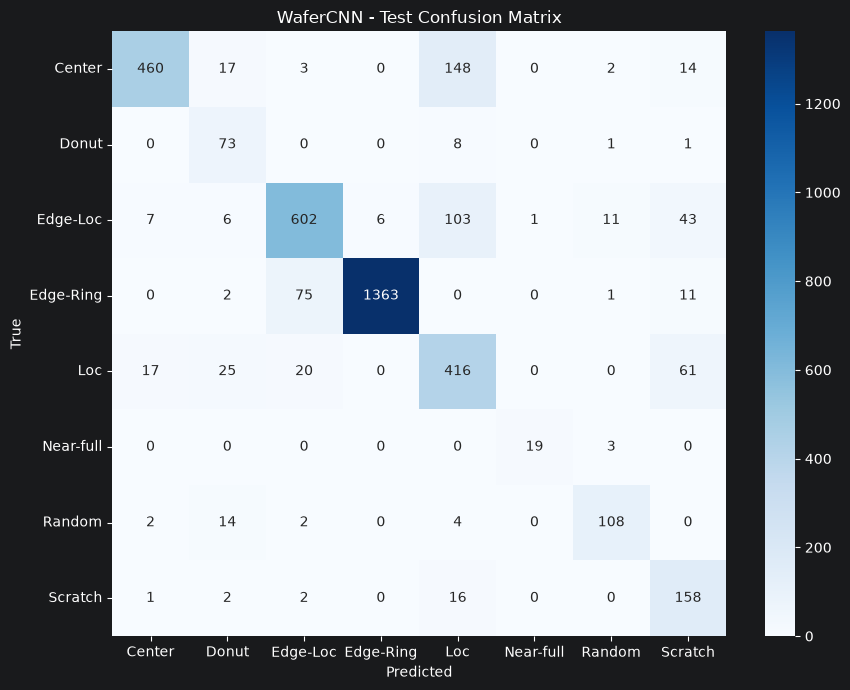

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the best checkpoint, not the last-epoch weights
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

# Evaluate once on the held-out test set
test_loss, test_preds, test_labels = evaluate(model=model, loader=test_loader, criterion=criterion, device=DEVICE)
print(f"Test loss: {test_loss:.4f}")

# Per class precision, recall, and F1 - the real evaluation
print(classification_report(y_true=test_labels, y_pred=test_preds, target_names=LABELS, digits=3))

# Confusion matrix
cm = confusion_matrix(y_true=test_labels, y_pred=test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("WaferCNN - Test Confusion Matrix")
plt.tight_layout()

cm_path = MODEL_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=120, bbox_inches="tight")
plt.show()
# print(f"Saved confusion matrix to {cm_path}")cm_path



# Baseline model Diagnosis & Next steps
The baseline CNN reaches ** macro-F1 0.785 / accuracy 0.833 ** on the held-out test set - a healthy starting point for a ~94k-param model trained from scratch. The confusion matrix reveals where it actually strugglesm which overturns out initial assumption.

### What the confusion matrix shows

**1. Rare classes are not the problem.**

Near-full (the rarest class, 22 test samples) has the recall of 1.000 - the model misses none of them. This confirms `WeightRandomSampler` is working as expected: oversampling gave the rare classes enough signal to be learned. Near-full precision is lower at 0.564, i.e. the model occasionally over-predicts it - an acceptable trade-off and a known side effect of oversampling.

**2. The real weakness is the Center <-> Loc confusion.**

186 treu-Center wafers are misclassified as Loc, dragging Center recall down to 0.668. Loc itself is the weaknest class (F1 0.647): its column absorbs the errors from Center, Edge-Loc, and Scratch, with precision 0.576. Loc is acting as a "catch-all" - when the model is unsure, it predicts Loc.

**3. Edge-Loc <-> Edge-Ring confusion (105 wafers).**

Geometrically, reasonable - both are edge-region defects with similar shapes. Less concerning than the Loc catch-all behavior.

### Diagnosing the val_loss instability

During training, `val_loss` oscillated sharply. The confusion matrix rules out the rare-class hypothesis: the small classes are well-classified, so the instability is **global oscillation**, not noise from tiny class supports. The root cause is a **fixed learning rate (1e-3) that stays too high late in training** - large update steps make the model bounce around the optimum instead of settling.

### Three possible directions

| Option                            | What it does                                                                    | Cost    | When                                          |
|-----------------------------------|---------------------------------------------------------------------------------|---------|-----------------------------------------------|
| **A. LR scheduler**               | Reduce LR when val_loss stalls → smoother convergence, possibly higher macro-F1 | ~10 min | **Now** — diagnosis confirmed LR is the cause |
| **B. ResNet-18 from scratch**     | Higher capacity may resolve Center/Loc confusion on its own                     | longer  | After baseline is finalized                   |
| **C. Inspect Center→Loc samples** | Visualize misclassified wafers to understand the confusion                      | short   | Better handled later via Grad-CAM             |

We proceed with **Option A first** (cheap, diagnosis-confirmed), keeping the original run for a
clean before/after comparison in MLflow, then move to Option B (ResNet-18) with a solid,
finalized baseline as the comparison anchor.

### Why ReduceLROnPlateau (not a fixed schedule)

`ReduceLROnPlateau` watches val_loss and only lowers the LR when improvement stalls — it reacts
to the actual training signal rather than following a predetermined curve. This directly targets
the observed symptom (val_loss plateauing then bouncing), which is the principled choice given
what the diagnosis showed.

In [11]:
# Fresh model + optimizer so this run trains from scratch. Class is still defined once in the above cell.
model = WaferCNN().to(device=DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.5,
                                                       patience=3)  # LR scheduler: halve learning rate after val_loss stalls for 3 epochs

run_params = {
    "model": "WaferCNN",
    "epochs": EPOCHS,
    "batch_size": BATCH,
    "lr": LR,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss",
    "sampler": "WeightedRandomSampler",
    "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
    "seed": SEED,
    "img_size": 64,
    "num_classes": NUM_CLASSES,
}

with mlflow.start_run(run_name="baseline-cnn-scheduler"):
    mlflow.log_params(run_params)
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
                                     device=DEVICE)
        val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion, device=DEVICE)
        scheduler.step(val_loss)
        val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")
        scheduler.step(val_loss)  # feed val_loss to scheduler
        current_lr = optimizer.param_groups[0]["lr"]

        mlflow.log_metrics(
            metrics={
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_macro_f1": val_macro_f1,
                "lr": current_lr,
            }, step=epoch
        )
        print(
            f"epoch {epoch:2d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | val macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
            mlflow.log_artifact(str(best_path))
            print(f"\t-> saved best (val_loss {val_loss:.4f})")

print(f"\nDone! Best val_loss: {best_val_loss:.4f}")

epoch  1 | train loss: 1.1088 | val loss: 0.9610 | val macro-F1: 0.5114 | lr: 0.0010
epoch  2 | train loss: 0.8086 | val loss: 0.8097 | val macro-F1: 0.5747 | lr: 0.0010
epoch  3 | train loss: 0.7049 | val loss: 0.8911 | val macro-F1: 0.5879 | lr: 0.0010
epoch  4 | train loss: 0.6503 | val loss: 0.7778 | val macro-F1: 0.6454 | lr: 0.0010
epoch  5 | train loss: 0.6159 | val loss: 0.5777 | val macro-F1: 0.7107 | lr: 0.0010
epoch  6 | train loss: 0.5793 | val loss: 1.0162 | val macro-F1: 0.5659 | lr: 0.0010
epoch  7 | train loss: 0.5360 | val loss: 0.5853 | val macro-F1: 0.7235 | lr: 0.0005
epoch  8 | train loss: 0.4993 | val loss: 0.5824 | val macro-F1: 0.6926 | lr: 0.0005
epoch  9 | train loss: 0.4741 | val loss: 0.5792 | val macro-F1: 0.7085 | lr: 0.0003
epoch 10 | train loss: 0.4600 | val loss: 0.6173 | val macro-F1: 0.7131 | lr: 0.0003
epoch 11 | train loss: 0.4440 | val loss: 0.5352 | val macro-F1: 0.7002 | lr: 0.0003
epoch 12 | train loss: 0.4344 | val loss: 0.4942 | val macro-F1: 

Test loss: 0.4157
              precision    recall  f1-score   support

      Center      0.907     0.739     0.814       644
       Donut      0.722     0.783     0.751        83
    Edge-Loc      0.794     0.881     0.835       779
   Edge-Ring      0.992     0.953     0.972      1452
         Loc      0.644     0.644     0.644       539
   Near-full      0.786     1.000     0.880        22
      Random      0.799     0.915     0.853       130
     Scratch      0.571     0.760     0.652       179

    accuracy                          0.845      3828
   macro avg      0.777     0.834     0.800      3828
weighted avg      0.855     0.845     0.847      3828



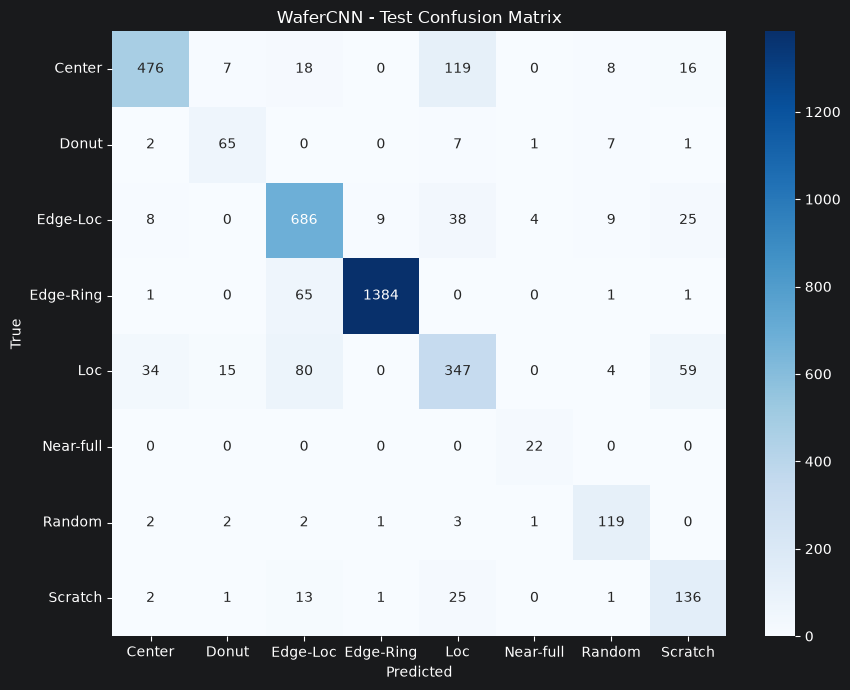

In [12]:
# Load the best checkpoint, not the last-epoch weights
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

# Evaluate once on the held-out test set
test_loss, test_preds, test_labels = evaluate(model=model, loader=test_loader, criterion=criterion, device=DEVICE)
print(f"Test loss: {test_loss:.4f}")

# Per class precision, recall, and F1 - the real evaluation
print(classification_report(y_true=test_labels, y_pred=test_preds, target_names=LABELS, digits=3))

# Confusion matrix
cm = confusion_matrix(y_true=test_labels, y_pred=test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("WaferCNN - Test Confusion Matrix")
plt.tight_layout()

cm_path = MODEL_DIR / "confusion_matrix_scheduler.png"
plt.savefig(cm_path, dpi=120, bbox_inches="tight")
plt.show()
# print(f"Saved confusion matrix to {cm_path}")

In [13]:
def run_experiment(model, run_name, train_loader, val_loader, epochs=EPOCHS, lr=LR, es_patience=7):
    """Train a model with Mlflow logging, LR scheduling, and early stopping. Returns the path to the best checkpoint by val_loss"""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.5, patience=3)
    best_val_loss = float("inf")
    epochs_no_improve = 0
    MODEL_DIR.mkdir(exist_ok=True)
    best_path = MODEL_DIR / f"{run_name}_best.pt"
    run_params = {
        "model": run_name,
        "epochs": epochs,
        "batch_size": BATCH,
        "lr": lr,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "sampler": "WeightedRandomSampler",
        "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
        "early_stopping_patience": es_patience,
        "seed": SEED,
        "img_size": 64,
        "num_classes": NUM_CLASSES,
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(run_params)
        for epoch in range(1, epochs + 1):
            train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
                                         device=DEVICE)
            val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion,
                                                       device=DEVICE)
            val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")

            scheduler.step(metrics=val_loss)
            current_lr = optimizer.param_groups[0]["lr"]

            mlflow.log_metrics(
                {"train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_macro_f1, "lr": current_lr},
                step=epoch)

            print(
                f"epoch {epoch:2d} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.2e}")

            # track the best + early stopping counter
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), best_path)
                mlflow.log_artifact(str(best_path))
                print(f"\t-> saved best (val_loss {val_loss:.4f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= es_patience:
                    print(f"\t-> early stopping at epoch {epoch} (no improvement for {epochs_no_improve} epochs)")
                    break
    print(f"Done! Best val_loss: {best_val_loss:.4f}")
    return best_path

In [14]:
def evaluate_and_report(best_path, model, loader, title, device=DEVICE):
    """Load best checkpoint, run per-class report + confusion matrix on loader"""
    model = model.to(device=device)
    model.load_state_dict(torch.load(best_path, map_location=device))
    test_loss, test_preds, test_labels = evaluate(model=model, loader=loader, criterion=criterion, device=device)
    print(f"Test loss for {title}: {test_loss:.4f}")
    print(classification_report(y_true=test_labels, y_pred=test_preds, target_names=LABELS, digits=3))

    cm = confusion_matrix(y_true=test_labels, y_pred=test_preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{title} - Test Confusion Matrix")
    plt.tight_layout()

    cm_path = MODEL_DIR / f"{title}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=120, bbox_inches="tight")
    plt.show()
    # print(f"Saved confusion matrix to {cm_path}")
    return cm_path

epoch  1 | train 1.1154 | val_loss 0.8989 | val_macro-F1: 0.5587 | lr: 1.00e-03
	-> saved best (val_loss 0.8989)
epoch  2 | train 0.8173 | val_loss 0.8099 | val_macro-F1: 0.6402 | lr: 1.00e-03
	-> saved best (val_loss 0.8099)
epoch  3 | train 0.7256 | val_loss 0.6606 | val_macro-F1: 0.6622 | lr: 1.00e-03
	-> saved best (val_loss 0.6606)
epoch  4 | train 0.6610 | val_loss 0.9436 | val_macro-F1: 0.4787 | lr: 1.00e-03
epoch  5 | train 0.6308 | val_loss 0.6197 | val_macro-F1: 0.6751 | lr: 1.00e-03
	-> saved best (val_loss 0.6197)
epoch  6 | train 0.5822 | val_loss 0.6219 | val_macro-F1: 0.6117 | lr: 1.00e-03
epoch  7 | train 0.5528 | val_loss 0.7538 | val_macro-F1: 0.5516 | lr: 1.00e-03
epoch  8 | train 0.5328 | val_loss 0.5154 | val_macro-F1: 0.6981 | lr: 1.00e-03
	-> saved best (val_loss 0.5154)
epoch  9 | train 0.5186 | val_loss 0.7927 | val_macro-F1: 0.6428 | lr: 1.00e-03
epoch 10 | train 0.4869 | val_loss 0.4756 | val_macro-F1: 0.7862 | lr: 1.00e-03
	-> saved best (val_loss 0.4756)
ep

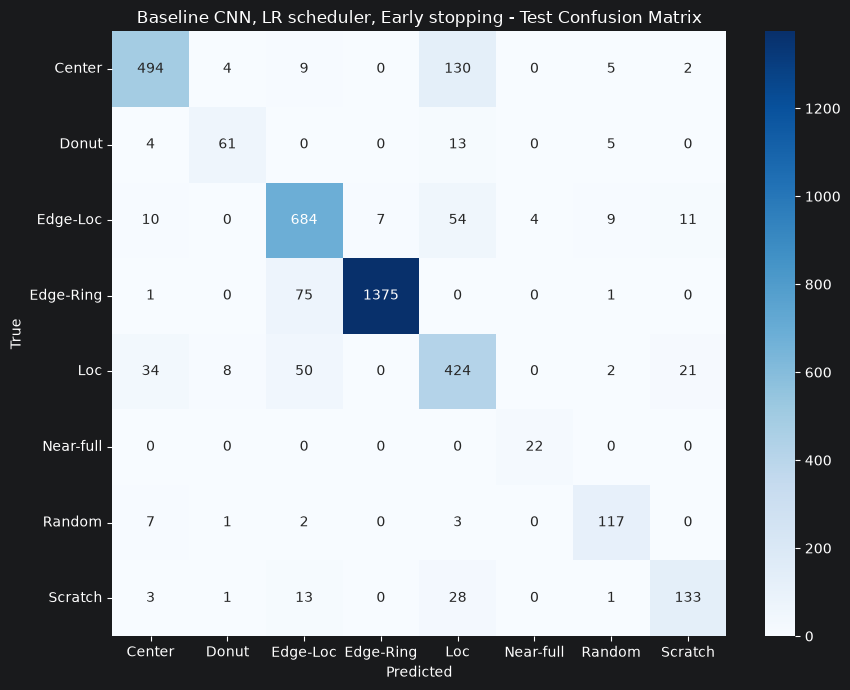

In [15]:
cnn = WaferCNN()
cnn_best_path = run_experiment(model=cnn, run_name="baseline-cnn-scheduler-earlystop", train_loader=train_loader,
                               val_loader=val_loader)
_ = evaluate_and_report(best_path=cnn_best_path, model=cnn, loader=test_loader,
                        title="Baseline CNN, LR scheduler, Early stopping")

In [16]:
def run_experiment_f1(model, run_name, train_loader, val_loader, epochs=EPOCHS, lr=LR, es_patience=7):
    """Train a model with Mlflow logging, LR scheduling, and early stopping. Returns the path to the best checkpoint by val macro-F1"""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.5, patience=3)
    best_val_f1 = -float("inf")
    epochs_no_improve = 0
    MODEL_DIR.mkdir(exist_ok=True)
    best_path = MODEL_DIR / f"{run_name}_best.pt"
    run_params = {
        "model": run_name,
        "epochs": epochs,
        "batch_size": BATCH,
        "lr": lr,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "sampler": "WeightedRandomSampler",
        "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
        "early_stopping_patience": es_patience,
        "seed": SEED,
        "img_size": 64,
        "num_classes": NUM_CLASSES,
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(run_params)
        for epoch in range(1, epochs + 1):
            train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
                                         device=DEVICE)
            val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion,
                                                       device=DEVICE)
            val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")

            scheduler.step(metrics=val_loss)  # scheduler react to loss not F1
            current_lr = optimizer.param_groups[0]["lr"]

            mlflow.log_metrics(
                {"train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_macro_f1, "lr": current_lr},
                step=epoch
            )

            print(
                f"epoch {epoch:2d} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.2e}"
            )

            # track the best + early stopping counter
            if val_macro_f1 > best_val_f1:
                best_val_f1 = val_macro_f1
                epochs_no_improve = 0
                torch.save(model.state_dict(), best_path)
                mlflow.log_artifact(str(best_path))
                print(f"\t-> saved best (val_macro-F1 {val_macro_f1:.4f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= es_patience:
                    print(f"\t-> early stopping at epoch {epoch} (no improvement for {epochs_no_improve} epochs)")
                    break

    print(f"Done! Best val_macro-F1: {best_val_f1:.4f}")
    return best_path

epoch  1 | train 1.1258 | val_loss 0.9217 | val_macro-F1: 0.5673 | lr: 1.00e-03
	-> saved best (val_loss 0.9217)
epoch  2 | train 0.8102 | val_loss 1.6561 | val_macro-F1: 0.4100 | lr: 1.00e-03
epoch  3 | train 0.7114 | val_loss 1.5542 | val_macro-F1: 0.3927 | lr: 1.00e-03
epoch  4 | train 0.6533 | val_loss 0.7235 | val_macro-F1: 0.6612 | lr: 1.00e-03
	-> saved best (val_loss 0.7235)
epoch  5 | train 0.6086 | val_loss 0.6553 | val_macro-F1: 0.6694 | lr: 1.00e-03
	-> saved best (val_loss 0.6553)
epoch  6 | train 0.5716 | val_loss 1.1704 | val_macro-F1: 0.4903 | lr: 1.00e-03
epoch  7 | train 0.5372 | val_loss 0.7315 | val_macro-F1: 0.6533 | lr: 1.00e-03
epoch  8 | train 0.5047 | val_loss 1.3220 | val_macro-F1: 0.5215 | lr: 1.00e-03
epoch  9 | train 0.4921 | val_loss 1.8641 | val_macro-F1: 0.4430 | lr: 5.00e-04
epoch 10 | train 0.4507 | val_loss 0.7201 | val_macro-F1: 0.6258 | lr: 5.00e-04
epoch 11 | train 0.4343 | val_loss 0.5138 | val_macro-F1: 0.7088 | lr: 5.00e-04
	-> saved best (val_l

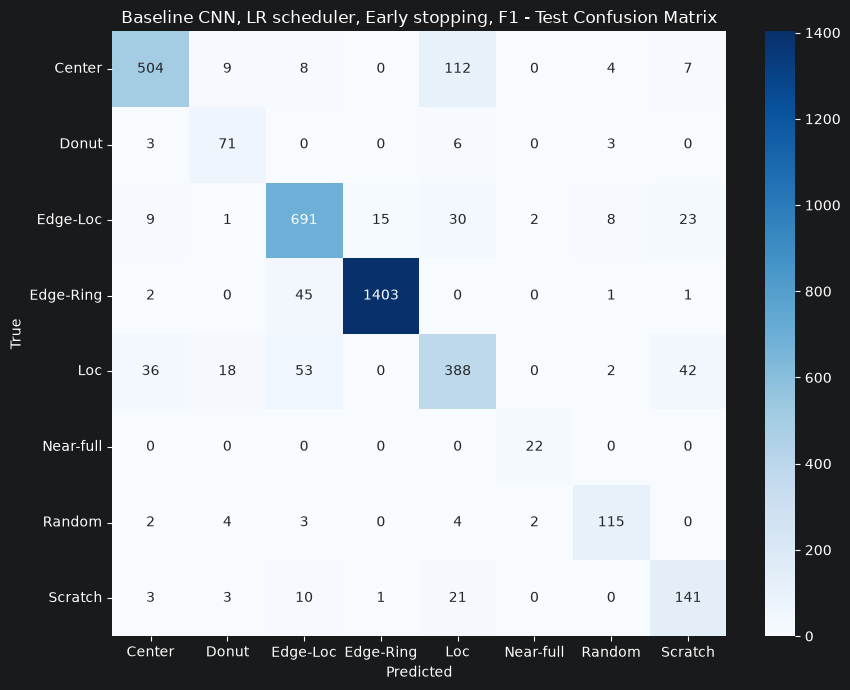

In [17]:
cnn = WaferCNN()
cnn_best_path = run_experiment(
    model=cnn,
    run_name="baseline-cnn-scheduler-earlystop-f1",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    es_patience=15,
)
_ = evaluate_and_report(
    best_path=cnn_best_path,
    model=cnn,
    loader=test_loader,
    title="Baseline CNN, LR scheduler, Early stopping, F1",
)

In [18]:
def run_experiment_f1_checkpoint_only(
        model, run_name, train_loader, val_loader, epochs=EPOCHS, lr=LR, es_patience=7
):
    """Train a model with Mlflow logging, LR scheduling, and early stopping. Returns the path to the best checkpoint by val macro-F1"""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizer, mode="min", factor=0.5, patience=3
    )
    best_val_f1 = -float("inf")
    best_val_loss = float("inf")
    epochs_no_improve = 0
    MODEL_DIR.mkdir(exist_ok=True)
    best_path = MODEL_DIR / f"{run_name}_best.pt"
    run_params = {
        "model": run_name,
        "epochs": epochs,
        "batch_size": BATCH,
        "lr": lr,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "sampler": "WeightedRandomSampler",
        "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
        "early_stopping_patience": es_patience,
        "seed": SEED,
        "img_size": 64,
        "num_classes": NUM_CLASSES,
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(run_params)
        for epoch in range(1, epochs + 1):
            train_loss = train_one_epoch(
                model=model,
                loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=DEVICE,
            )
            val_loss, val_preds, val_labels = evaluate(
                model=model, loader=val_loader, criterion=criterion, device=DEVICE
            )
            val_macro_f1 = f1_score(
                y_true=val_labels, y_pred=val_preds, average="macro"
            )

            scheduler.step(metrics=val_loss)  # scheduler react to loss not F1
            current_lr = optimizer.param_groups[0]["lr"]

            mlflow.log_metrics(
                {
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "val_macro_f1": val_macro_f1,
                    "lr": current_lr,
                },
                step=epoch,
            )

            print(
                f"epoch {epoch:2d} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.2e}"
            )

            # track the best macro-F1 to save the best model
            if val_macro_f1 > best_val_f1:
                best_val_f1 = val_macro_f1
                torch.save(model.state_dict(), best_path)
                mlflow.log_artifact(str(best_path))
                print(f"\t-> saved best (val_macro-F1 {val_macro_f1:.4f})")

            # track the best val_loss to update the early stopping counter
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                print(f"\t-> saved best (val_loss {val_loss:.4f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= es_patience:
                    print(
                        f"\t-> early stopping at epoch {epoch} (no improvement for {epochs_no_improve} epochs)"
                    )
                    break

    print(f"Done! Best val_macro-F1: {best_val_f1:.4f}")
    return best_path

epoch  1 | train 1.1224 | val_loss 1.3169 | val_macro-F1: 0.4975 | lr: 1.00e-03
	-> saved best (val_macro-F1 0.4975)
	-> saved best (val_loss 1.3169)
epoch  2 | train 0.8112 | val_loss 0.9032 | val_macro-F1: 0.6281 | lr: 1.00e-03
	-> saved best (val_macro-F1 0.6281)
	-> saved best (val_loss 0.9032)
epoch  3 | train 0.7025 | val_loss 0.8772 | val_macro-F1: 0.5858 | lr: 1.00e-03
	-> saved best (val_loss 0.8772)
epoch  4 | train 0.6545 | val_loss 0.7263 | val_macro-F1: 0.5545 | lr: 1.00e-03
	-> saved best (val_loss 0.7263)
epoch  5 | train 0.6137 | val_loss 0.7661 | val_macro-F1: 0.6720 | lr: 1.00e-03
	-> saved best (val_macro-F1 0.6720)
epoch  6 | train 0.5678 | val_loss 0.5196 | val_macro-F1: 0.7272 | lr: 1.00e-03
	-> saved best (val_macro-F1 0.7272)
	-> saved best (val_loss 0.5196)
epoch  7 | train 0.5466 | val_loss 0.7451 | val_macro-F1: 0.6555 | lr: 1.00e-03
epoch  8 | train 0.5300 | val_loss 0.6773 | val_macro-F1: 0.6509 | lr: 1.00e-03
epoch  9 | train 0.4998 | val_loss 1.9915 | val

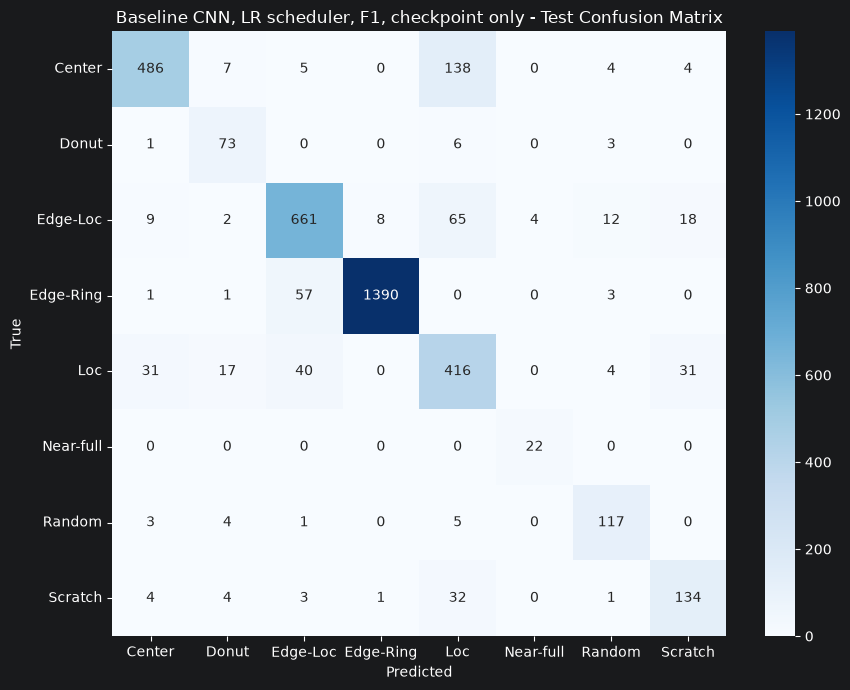

In [19]:
cnn = WaferCNN()
cnn_best_path = run_experiment_f1_checkpoint_only(
    model=cnn,
    run_name="baseline-cnn-scheduler-f1-checkpoint-only",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    es_patience=15,
)
_ = evaluate_and_report(
    best_path=cnn_best_path,
    model=cnn,
    loader=test_loader,
    title="Baseline CNN, LR scheduler, F1, checkpoint only",
)

In [23]:
import torch.nn as nn
import torch.nn.functional as F


class BasicBlock(nn.Module):
    """Standard ResNet BasicBlock: two 3x3 conv with a residual connection
    The skip connection is the whole point of ResNet: it lets the gradient flow directly past the conv layers (identity path), so deep networks stay trainable instead of degrading. expansion=1 means output channels == `out_channels`
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        # First conv carries the stride: this is where spatial downsampling happens
        # at the start of stages 2/3/4 (stride=2). padding=1 keep 3x3 size-preserving
        # when stride=1. bias=False because BN right after subtracts the mean,
        # which cancels any constant bias - BN beta does the shifting instead.
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        # BatchNorm3d(c): keep one (mean, var) pair per output channel computed over batch (batch x H x W)
        # plus one learnable (gamma, beta) pair per channel
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1,
                               bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # down sample: a 1x1 conv (+BN) applied to the identity shortcut, use only when the
        # shortcut's shape doesn't match the main path - i.e. channels changed or
        # stride halved the spatial size. Without it, `out + identity` crashes on
        # shape mismatch. Built by _make_layer and passed in (None for most blocks).
        self.downsample = downsample

    def forward(self, x):
        identity = x

        # Main path: conv -> BN -> ReLU, then conv -> BN (no ReLU yet)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Match the shorcut's shape to out if needed.
        if self.downsample is not None:
            identity = self.downsample(x)

        # The residual add, then ReLU (post activation)
        # ReLU comes after the add so the identity signal passes through un-clipped
        out += identity
        return F.relu(out)


In [28]:
class WaferResNet18(nn.Module):
    """ResNet-18 from scratch for 1-channl 64x64 wafer maps, 8 classes.
    Deviations from the ImageNet original:
        - Stem is a 3x3 stride-1 conv, no maxpool (ImageNet uses 7x7 stride-2 + maxpool, which downsamples 4x immediately -- too aggressive for a 64x64 input)
        - conv1 takes 1 input channel (wafer is single-channel), fc outputs 8 classes. The core (BasicBlock, [2,2,2,2] layout, 64->128->256->512, stride-2 stage starts) is standard ResNet-18
    """

    def __init__(self, num_classes=NUM_CLASSES, in_channels=1):
        super().__init__()
        # Running channel count while BUILDING the network. Starts at 64 because that's how many channels exist right after the stem, _make_layer reads and updates it.
        self.in_channels = 64

        # Stem: 1 -> 64 channels, keeps 64x64 (kernel 3 + padding 1, stride 1)
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # 4 stages, each = num_blocks BasicBlock. Spatial 64->64->32->16->8
        self.layer1 = self._make_layer(out_channels=64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(out_channels=128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(out_channels=256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(out_channels=512, num_blocks=2, stride=2)

        # Head: pool each channel's 8x8 map to a single number, then classify.
        self.avgpool = nn.AdaptiveAvgPool2d(1)  # 512x8x8 -> 512x1x1
        self.fc = nn.Linear(in_features=512, out_features=num_classes)  # 512 -> 8

        self._init_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        """Build of stage of num_blocks BasicBlock. Only the FIRST block may change shape (it carries the stride and/or the channel change), so only it may need a downsample on its shortcut. The remaining blocks are stride-1, same-channel -> no-downsample
        """
        downsample = None
        # A projection shortcut is needed only if the shortcut's shape won't match the main path
        # either the spatial size shrinks (stride!=1) or the channel count change (self.in_channels != self.out_channels)
        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels=self.in_channels, out_channels=out_channels * BasicBlock.expansion, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion),
            )

        # First block: uses the incoming self.in_channels, applies stride + downsample
        layers = [
            BasicBlock(in_channels=self.in_channels, out_channels=out_channels, stride=stride, downsample=downsample)]
        # After the first block the running channel count becomes out_channels
        self.in_channels = out_channels * BasicBlock.expansion
        # Remaining blocks: in == out channels, stride 1, no downsample
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(in_channels=self.in_channels, out_channels=out_channels))
        return nn.Sequential(*layers)

    def _init_weights(self):
        """Kaiming init for conv weights matches ReLU, standard BN init"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Same normalization as WaferCNN, so the architecture comparison stays clean
        x = x / 2.0  # discrete {0,1,2} -> {0,0.5,1.0}
        # Stem
        x = F.relu(self.bn1(self.conv1(x)))

        # 4 stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [30]:
# sanity check
_test_model = WaferResNet18().to(DEVICE)
_dummy = torch.randn(4, 1, 64, 64, device=DEVICE)  # batch=4, 1 channel, 64x64
with torch.no_grad():
    _out = _test_model(_dummy)
print(f"Output shape: {_out.shape} (expect torch.Size([4, {NUM_CLASSES}]))")

n_params = sum(p.numel() for p in _test_model.parameters())
print(f"Total params: {n_params:,} (expect ~11.2M for ResNet-18)")
del _test_model, _dummy, _out

Output shape: torch.Size([4, 8]) (expect torch.Size([4, 8]))
Total params: 11,171,784 (expect ~11.2M for ResNet-18)


In [31]:
resnet_best_path = run_experiment(WaferResNet18(), "resnet18-scratch", train_loader, val_loader)

epoch  1 | train 0.7392 | val_loss 0.8438 | val_macro-F1: 0.5962 | lr: 1.00e-03
	-> saved best (val_loss 0.8438)
epoch  2 | train 0.4307 | val_loss 0.4358 | val_macro-F1: 0.7756 | lr: 1.00e-03
	-> saved best (val_loss 0.4358)
epoch  3 | train 0.2708 | val_loss 0.4406 | val_macro-F1: 0.8085 | lr: 1.00e-03
epoch  4 | train 0.2010 | val_loss 0.3468 | val_macro-F1: 0.8380 | lr: 1.00e-03
	-> saved best (val_loss 0.3468)
epoch  5 | train 0.1630 | val_loss 0.3474 | val_macro-F1: 0.8469 | lr: 1.00e-03
epoch  6 | train 0.1331 | val_loss 0.3930 | val_macro-F1: 0.8406 | lr: 1.00e-03
epoch  7 | train 0.1114 | val_loss 0.4526 | val_macro-F1: 0.8355 | lr: 1.00e-03
epoch  8 | train 0.0896 | val_loss 0.3754 | val_macro-F1: 0.8713 | lr: 5.00e-04
epoch  9 | train 0.0465 | val_loss 0.2401 | val_macro-F1: 0.8957 | lr: 5.00e-04
	-> saved best (val_loss 0.2401)
epoch 10 | train 0.0292 | val_loss 0.2595 | val_macro-F1: 0.8944 | lr: 5.00e-04
epoch 11 | train 0.0263 | val_loss 0.2862 | val_macro-F1: 0.8728 | l

Test loss for ResNet18 (test): 0.2623
              precision    recall  f1-score   support

      Center      0.919     0.972     0.945       644
       Donut      0.910     0.735     0.813        83
    Edge-Loc      0.873     0.910     0.891       779
   Edge-Ring      0.992     0.973     0.982      1452
         Loc      0.829     0.811     0.820       539
   Near-full      0.957     1.000     0.978        22
      Random      0.919     0.877     0.898       130
     Scratch      0.858     0.810     0.833       179

    accuracy                          0.921      3828
   macro avg      0.907     0.886     0.895      3828
weighted avg      0.922     0.921     0.921      3828



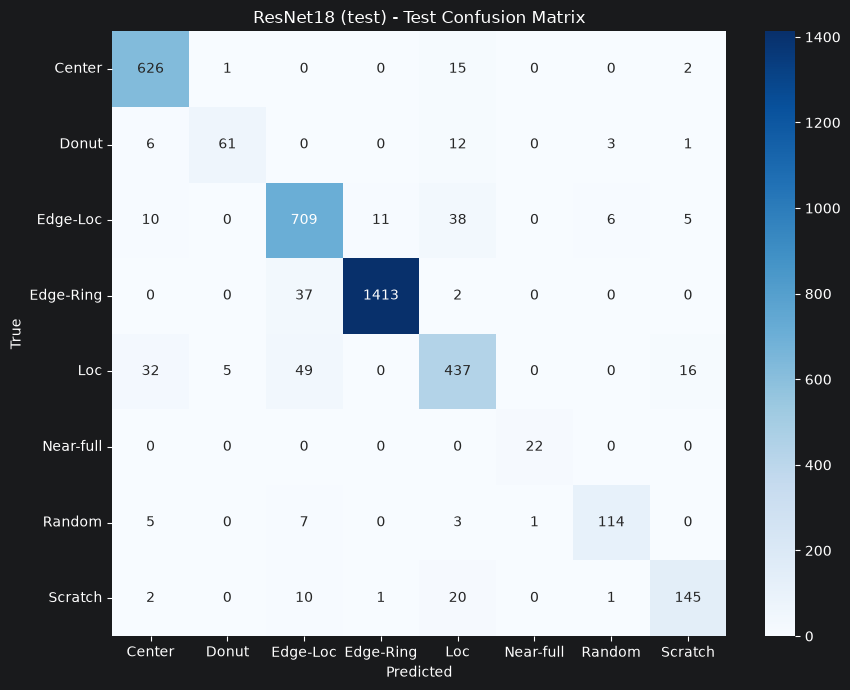

In [33]:
_ = evaluate_and_report(resnet_best_path, WaferResNet18(), test_loader, "ResNet18 (test)")